<a href="https://colab.research.google.com/github/tsnuhithreddy/ADM_LAB_10H9/blob/main/ADM_FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install if not already installed (uncomment if needed)
# !pip install vaderSentiment
# !pip install wordcloud
import pandas as pd
import random
from datetime import datetime, timedelta
import nltk
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from google.colab import files
# Download necessary nltk resources
nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Load the dataset (replace with your file name if different)
df = pd.read_csv('/content/zomato_tweets_simulated_1000.csv')

# Text cleaning function
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # remove URLs
    text = re.sub(r'\@[\w]*', '', text)  # remove @mentions
    text = re.sub(r'\#[\w]*', '', text)  # remove hashtags
    text = re.sub(r'[^A-Za-z\s]', '', text)  # remove punctuations, numbers, emojis
    text = text.lower().strip()  # lowercase and strip
    return text

# Apply text cleaning
df['Clean_Tweet'] = df['Tweet'].apply(clean_text)

# Display first few rows
df.head()

,Date,Tweet,User,Clean_Tweet
0,2025-04-02,Got a free dessert with my Zomato order today!...,user_581,got a free dessert with my zomato order today yay
1,2025-04-05,Zomato app crashed again. Annoying experience.,user_166,zomato app crashed again annoying experience
2,2025-04-21,Zomato should improve their packaging. Spilled...,user_738,zomato should improve their packaging spilled ...
3,2025-04-01,Got a free dessert with my Zomato order today!...,user_632,got a free dessert with my zomato order today yay
4,2025-04-07,"I love ordering from Zomato, food is always ho...",user_141,i love ordering from zomato food is always hot...


In [ ]:
# Initialize VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

def get_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df['Compound'] = df['Clean_Tweet'].apply(lambda x: sid.polarity_scores(x)['compound'])
df['Sentiment'] = df['Compound'].apply(get_sentiment)

# Display sentiment results
df.head()


,Date,Tweet,User,Clean_Tweet,Compound,Sentiment
0,2025-04-02,Got a free dessert with my Zomato order today!...,user_581,got a free dessert with my zomato order today yay,0.7717,Positive
1,2025-04-05,Zomato app crashed again. Annoying experience.,user_166,zomato app crashed again annoying experience,-0.4019,Negative
2,2025-04-21,Zomato should improve their packaging. Spilled...,user_738,zomato should improve their packaging spilled ...,0.4404,Positive
3,2025-04-01,Got a free dessert with my Zomato order today!...,user_632,got a free dessert with my zomato order today yay,0.7717,Positive
4,2025-04-07,"I love ordering from Zomato, food is always ho...",user_141,i love ordering from zomato food is always hot...,0.8360,Positive


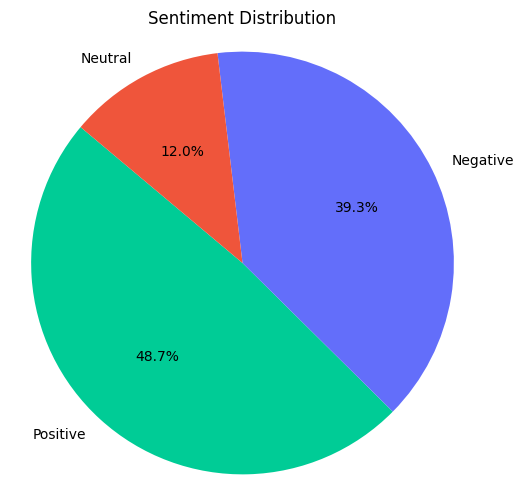

In [ ]:
# Sentiment distribution
sentiment_counts = df['Sentiment'].value_counts()
colors = ['#00cc96', '#636efa', '#ef553b']

# Plot the pie chart
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Sentiment Distribution")
plt.axis('equal')
plt.show()


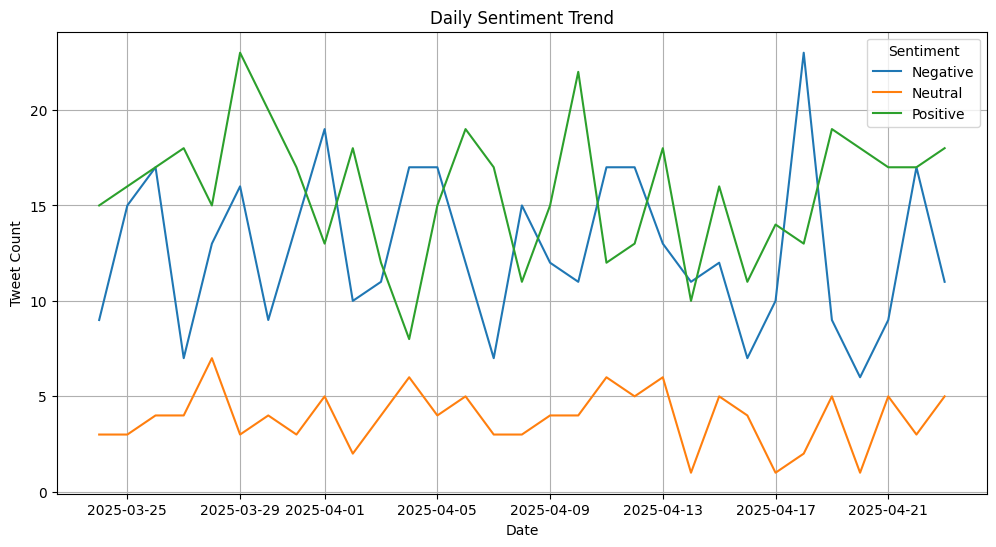

In [ ]:
# Convert 'Date' to datetime and group by
df['Date'] = pd.to_datetime(df['Date'])
trend = df.groupby([df['Date'].dt.date, 'Sentiment']).size().unstack().fillna(0)

# Plot sentiment trend over time
trend.plot(kind='line', figsize=(12,6))
plt.title("Daily Sentiment Trend")
plt.ylabel("Tweet Count")
plt.xlabel("Date")
plt.grid(True)
plt.show()


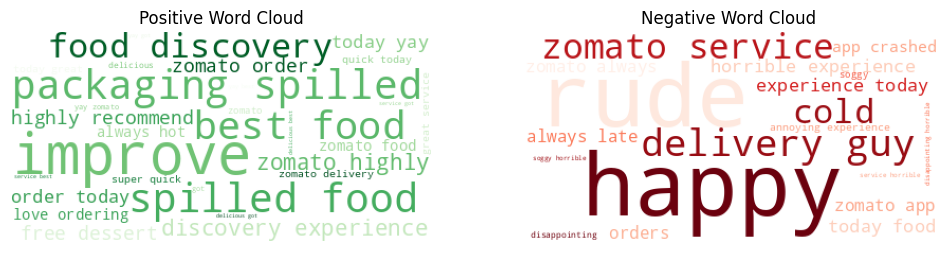

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

stop_words = set(STOPWORDS)

# Separate positive and negative tweets
positive_words = ' '.join(df[df['Sentiment'] == 'Positive']['Clean_Tweet'])
negative_words = ' '.join(df[df['Sentiment'] == 'Negative']['Clean_Tweet'])

# Plot WordCloud for Positive Sentiment
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(WordCloud(stopwords=stop_words, background_color='white', colormap='Greens').generate(positive_words))
plt.axis('off')
plt.title("Positive Word Cloud")

# Plot WordCloud for Negative Sentiment
plt.subplot(1,2,2)
plt.imshow(WordCloud(stopwords=stop_words, background_color='white', colormap='Reds').generate(negative_words))
plt.axis('off')
plt.title("Negative Word Cloud")
plt.show()


In [ ]:
# Summary of sentiment distribution
sentiment_summary = df['Sentiment'].value_counts()
sentiment_percentage = (sentiment_summary / sentiment_summary.sum()) * 100

print("Sentiment Distribution Summary:")
print(sentiment_summary)
print("\nSentiment Percentage:")
print(sentiment_percentage)


Sentiment Distribution Summary:
Sentiment
Positive    487
Negative    393
Neutral     120
Name: count, dtype: int64

Sentiment Percentage:
Sentiment
Positive    48.7
Negative    39.3
Neutral     12.0
Name: count, dtype: float64


In [ ]:
df.to_csv('zomato_tweets_sentiment.csv', index=False)
print("Data saved to zomato_tweets_sentiment.csv")

Data saved to zomato_tweets_sentiment.csv


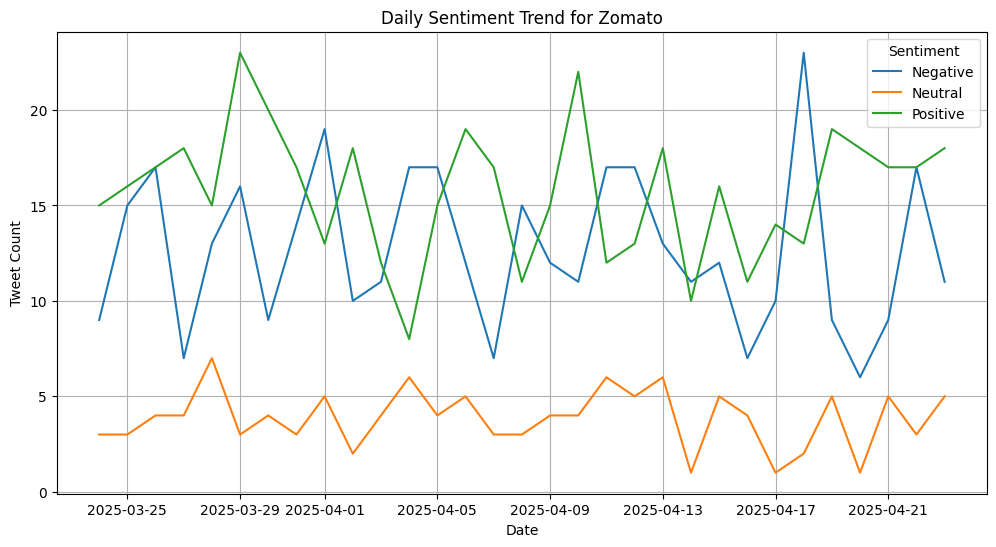

In [ ]:
# Sentiment trend analysis over time (group by date and sentiment)
trend = df.groupby([df['Date'].dt.date, 'Sentiment']).size().unstack().fillna(0)

# Plot sentiment trend over time
trend.plot(kind='line', figsize=(12,6))
plt.title("Daily Sentiment Trend for Zomato")
plt.ylabel("Tweet Count")
plt.xlabel("Date")
plt.grid(True)
plt.show()


In [ ]:
from collections import Counter

# For positive tweets
positive_tweets = df[df['Sentiment'] == 'Positive']['Clean_Tweet']
positive_words = ' '.join(positive_tweets)
positive_word_freq = Counter(positive_words.split())
positive_most_common = positive_word_freq.most_common(10)

# For negative tweets
negative_tweets = df[df['Sentiment'] == 'Negative']['Clean_Tweet']
negative_words = ' '.join(negative_tweets)
negative_word_freq = Counter(negative_words.split())
negative_most_common = negative_word_freq.most_common(10)

# Display the most common words
print("Most Common Words in Positive Tweets:")
print(positive_most_common)
print("\nMost Common Words in Negative Tweets:")
print(negative_most_common)


Most Common Words in Positive Tweets:
[('zomato', 487), ('food', 303), ('today', 184), ('should', 106), ('improve', 106), ('their', 106), ('packaging', 106), ('spilled', 106), ('again', 106), ('best', 100)]

Most Common Words in Negative Tweets:
[('zomato', 290), ('was', 211), ('with', 201), ('experience', 192), ('the', 108), ('delivery', 108), ('guy', 108), ('rude', 108), ('not', 108), ('happy', 108)]


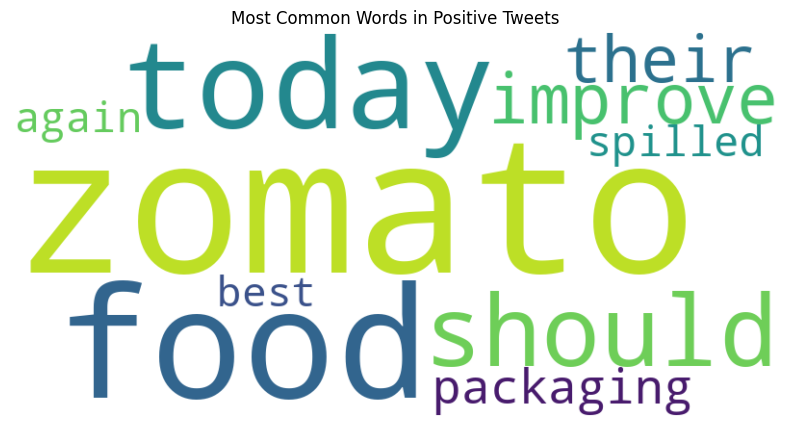

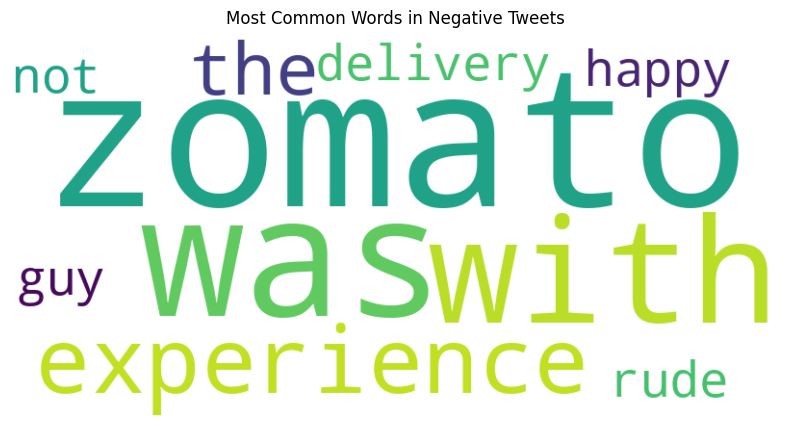

In [ ]:
# Most Common Words in Positive Tweets
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(positive_most_common))
plt.figure(figsize=(10,5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Most Common Words in Positive Tweets')
plt.axis('off')
plt.show()

# Most Common Words in Negative Tweets
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(negative_most_common))
plt.figure(figsize=(10,5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Most Common Words in Negative Tweets')
plt.axis('off')
plt.show()
